# XGBoost Pairwise Ranking for Recipe Recommendation

This notebook builds a query-level learning-to-rank pipeline with `XGBRanker(objective="rank:pairwise")`.
It uses only fields that already exist in this repository:

- `recipes_dataset_ver1.csv` for query-candidate labels
- `recipes_processed.json` for recipe metadata

The notebook:
1. Loads and merges the ranking labels with recipe metadata
2. Engineers query-recipe matching features
3. Splits the data by query to avoid leakage
4. Trains an XGBoost pairwise ranker
5. Evaluates with `NDCG`, `MRR`, and `HIT`
6. Shows feature importance and a small ablation
        


## I. Libraries Used

This notebook uses both Python standard libraries and machine learning/data analysis libraries to support data loading, preprocessing, feature engineering, model training, and evaluation.

- `json`, `os`: used for reading dataset files and handling file paths.
- `math`, `re`, `unicodedata`: used for mathematical calculations, regular expression matching, and Vietnamese text normalization.
- `time`: used to measure training and inference runtime.
- `Counter`, `defaultdict`, `lru_cache`: used for token counting, grouped evaluation results, and caching local model calls.
- `numpy`: used for numerical operations and array-based calculations.
- `pandas`: used for data loading, cleaning, merging, transformation, and tabular analysis.
- `matplotlib.pyplot`, `seaborn`: used for visualization such as feature importance plots, correlation heatmaps, and training curves.
- `torch`, `transformers`: used to load the free local `Qwen3` model for structured query parsing.
- `FlagEmbedding`: used to load `BAAI/bge-m3` for semantic similarity features.
- `ndcg_score`: used to evaluate ranking quality with NDCG.
- `train_test_split`: used to divide the data into train, validation, and test query groups.
- `XGBRanker`: the main learning-to-rank model used for pairwise recipe ranking.

The notebook also applies:
- `plt.style.use("seaborn-v0_8")` for cleaner plots
- `pd.set_option(...)` to display wider DataFrames more clearly
- `RANDOM_STATE = 42` to ensure reproducible results


In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("HF_HOME", r"D:\Cache\huggingface")
os.environ.setdefault("HF_HUB_CACHE", r"D:\Cache\huggingface\hub")
os.environ.setdefault("TRANSFORMERS_CACHE", r"D:\Cache\huggingface\hub")
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")
os.environ.setdefault("PIP_CACHE_DIR", r"D:\Cache\pip")
os.environ.setdefault("TEMP", r"D:\Temp")
os.environ.setdefault("TMP", r"D:\Temp")

for _cache_dir in [
    os.environ["HF_HOME"],
    os.environ["HF_HUB_CACHE"],
    os.environ["PIP_CACHE_DIR"],
    os.environ["TEMP"],
]:
    os.makedirs(_cache_dir, exist_ok=True)

import json
import math
import re
import time
import unicodedata
from collections import Counter, defaultdict
from functools import lru_cache

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from FlagEmbedding import BGEM3FlagModel
from sklearn.metrics import ndcg_score
from sklearn.model_selection import train_test_split
from transformers import AutoModelForCausalLM, AutoTokenizer
from xgboost import XGBRanker

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "scripts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "scripts") not in sys.path:
    sys.path.append(str(PROJECT_ROOT / "scripts"))

import query_constraint_parser

RANDOM_STATE = 42
QWEN_MODEL_NAME = os.getenv("QWEN_MODEL_NAME", "Qwen/Qwen3-1.7B")
BGE_MODEL_NAME = os.getenv("BGE_MODEL_NAME", "BAAI/bge-m3")
HF_CACHE_DIR = os.environ["HF_HUB_CACHE"]
QUERY_PARSER_BACKEND = os.getenv("QUERY_PARSER_BACKEND", "heuristic")
QUERY_CONSTRAINT_CACHE_PATH = PROJECT_ROOT / "dataset" / f"query_constraint_cache_{QUERY_PARSER_BACKEND}.json"



d:\Downloads\Python\Lib\site-packages\transformers\utils\hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


## Machine Learning pipeline

### Step 1: Loads and merges the ranking labels with recipe metadata

In [2]:
labels_path = os.path.join("..", "dataset", "recipes_dataset_ver1.csv")
recipes_path = os.path.join("..", "dataset", "recipes_processed.json")

labels_df = pd.read_csv(labels_path, encoding="utf-8")

with open(recipes_path, "r", encoding="utf-8") as f:
    recipes = json.load(f)

recipes_df = pd.DataFrame(recipes).copy()
recipes_df["recipe_id"] = recipes_df.index.astype(int)

df = labels_df.merge(
    recipes_df,
    on=["recipe_id", "dish_name"],
    how="left",
    validate="many_to_one",
)

print("Ranking rows:", len(df))
print("Unique queries:", df["query"].nunique())
print("Candidates per query summary:")
print(df.groupby("query").size().describe())
print("\nMerged columns:")
print(df.columns.tolist())


Ranking rows: 3750
Unique queries: 250
Candidates per query summary:
count    250.0
mean      15.0
std        0.0
min       15.0
25%       15.0
50%       15.0
75%       15.0
max       15.0
dtype: float64

Merged columns:
['query', 'dish_name', 'recipe_id', 'label', 'reason', 'source', 'url', 'difficulty', 'views', 'ingredients', 'instructions', 'category', 'prep_time_min', 'cook_time_min', 'servings_bin', 'cook_time_source', 'popularity']


### Step 2: 2. Engineers query-recipe matching features

In [3]:
# =========================
# Basic text helpers
# =========================

# STOPWORDS = cac tu pho bien se bi bo khi tokenize
STOPWORDS = {
    "toi", "la", "cho", "va", "1", "mon", "hay", "nao", "co", "khong", "thi",
    "de", "nau", "lam", "gi", "huong", "dan", "goi", "y", "can", "mot", "tu",
    "bang", "duoi", "tren", "deu", "nhung", "chi"
}

# POPULARITY_MAP = anh xa muc do pho bien tu text sang so
POPULARITY_MAP = {
    "rat thap": 1,
    "thap": 2,
    "trung binh": 3,
    "cao": 4,
    "rat cao": 5,
}


def normalize_text(text: str) -> str:
    # Dua van ban ve chu thuong, khong dau, bo ky tu dac biet
    if not isinstance(text, str):
        return ""
    text = text.lower().replace("\u0111", "d")
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"[^a-z0-9\s-]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def tokenize(text: str):
    # Tach tu va loai bo stopwords
    return [tok for tok in normalize_text(text).split() if tok and tok not in STOPWORDS]


def parse_servings_bin(value: str):
    # Doi chuoi nhu 4 hoac 4-6 thanh gia tri so dai dien
    nums = [int(x) for x in re.findall(r"\d+", normalize_text(value))]
    if not nums:
        return np.nan
    return float(nums[0]) if len(nums) == 1 else float(sum(nums[:2]) / 2)


def build_recipe_text(row):
    # Ghep ten mon, category va nguyen lieu thanh text dai dien cho recipe
    ingredient_names = []
    for item in row.get("ingredients", []) or []:
        name = str(item.get("name", "")).strip()
        if name:
            ingredient_names.append(name)

    parts = [
        str(row.get("dish_name", "")),
        str(row.get("category", "")),
        " ".join(ingredient_names),
    ]
    return " | ".join(part for part in parts if part)


In [4]:
# =========================
# LLM parser + embedding helpers
# =========================

_QWEN_TOKENIZER = None
_QWEN_MODEL = None
_BGE_MODEL = None

QWEN_PARSER_SYSTEM_PROMPT = """
Bạn là hệ thống trích xuất thông tin có cấu trúc từ truy vấn món ăn tiếng Việt.
Nhiệm vụ của bạn là đọc truy vấn người dùng và trả về DUY NHẤT một JSON hợp lệ.
Không giải thích, không thêm markdown, không thêm văn bản ngoài JSON.

Schema:
{
  "difficulty_target": 1 | 2 | 3 | null,
  "servings_target": number | null,
  "prep_time_limit_min": number | null,
  "cook_time_limit_min": number | null,
  "total_time_limit_min": number | null,
  "time_limit_min": number | null,
  "max_ingredients": number | null,
  "style_tags": [string],
  "categories": [string]
}

Ý nghĩa các trường:
- difficulty_target:
  - 1 = dễ, đơn giản, nhanh, ít bước, cho người mới
  - 2 = trung bình, vừa tay
  - 3 = khó, cầu kỳ, thử sức
- servings_target: số người ăn nếu truy vấn nêu rõ, ví dụ "4 người" hoặc "2-4 người"
- prep_time_limit_min: giới hạn riêng cho thời gian chuẩn bị, nếu có nói rõ
- cook_time_limit_min: giới hạn riêng cho thời gian nấu, nếu có nói rõ
- total_time_limit_min: giới hạn tổng thời gian, nếu có nói rõ
- time_limit_min: giới hạn thời gian tổng quát tốt nhất suy ra từ truy vấn
- max_ingredients: số lượng nguyên liệu tối đa nếu có nhắc như "không quá 5 nguyên liệu"
- style_tags: danh sách nhãn phong cách món ăn
- categories: danh sách nhãn loại món

Quy tắc suy luận:
- Nếu truy vấn nói chung "dưới 30 phút" hoặc "không quá 30 phút" mà không tách riêng chuẩn bị hay nấu, hãy điền vào total_time_limit_min và time_limit_min.
- Nếu có cả prep_time_limit_min, cook_time_limit_min, total_time_limit_min thì time_limit_min là mốc thời gian tổng quát phù hợp nhất.
- Nếu truy vấn không nói rõ một trường, dùng null cho số và [] cho danh sách.
- Chỉ trích xuất thông tin xuất hiện hợp lý trong truy vấn, không bịa thêm.
- Ưu tiên sự chính xác và nhất quán hơn là đoán rộng.

Danh sách nhãn categories hợp lệ:
- mon_nuong
- mon_canh
- mon_chao
- mon_xao
- mon_kho
- mon_chien
- mon_hap
- mon_banh
- mon_che
- mon_nuoc
- mon_kem
- mon_goi_salad
- mon_bun
- mon_lau
- mon_chay
- mon_an_vat
- mon_trang_mieng
- mon_kho_mam
- mon_cuon_tron
- sinh_to
- tra_sua
- nuoc_ep
- nuoc_cham
- meo_vao_bep

Danh sách nhãn style_tags hợp lệ:
- lanh_manh
- ngot_nhe
- cay_nhe
- dep_mat
- truyen_thong
- pho_bien
- it_gap

Ví dụ:
Truy vấn: "Tôi muốn làm món nướng cho 4 người, dưới 30 phút, ít dầu mỡ"
JSON:
{
  "difficulty_target": null,
  "servings_target": 4,
  "prep_time_limit_min": null,
  "cook_time_limit_min": null,
  "total_time_limit_min": 30,
  "time_limit_min": 30,
  "max_ingredients": null,
  "style_tags": ["lanh_manh"],
  "categories": ["mon_nuong"]
}

Truy vấn: "Gợi ý món canh dễ nấu cho 2 người"
JSON:
{
  "difficulty_target": 1,
  "servings_target": 2,
  "prep_time_limit_min": null,
  "cook_time_limit_min": null,
  "total_time_limit_min": null,
  "time_limit_min": null,
  "max_ingredients": null,
  "style_tags": [],
  "categories": ["mon_canh"]
}
""".strip()


def _get_default_torch_dtype():
    if torch.cuda.is_available():
        return torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    return torch.float32


def _get_qwen_parser():
    global _QWEN_TOKENIZER, _QWEN_MODEL

    if _QWEN_TOKENIZER is None or _QWEN_MODEL is None:
        _QWEN_TOKENIZER = AutoTokenizer.from_pretrained(
            QWEN_MODEL_NAME,
            trust_remote_code=True,
            cache_dir=HF_CACHE_DIR,
        )

        model_kwargs = {
            "torch_dtype": _get_default_torch_dtype(),
            "low_cpu_mem_usage": True,
            "trust_remote_code": True,
            "cache_dir": HF_CACHE_DIR,
        }
        if torch.cuda.is_available():
            model_kwargs["device_map"] = "auto"

        _QWEN_MODEL = AutoModelForCausalLM.from_pretrained(
            QWEN_MODEL_NAME,
            **model_kwargs,
        )
        _QWEN_MODEL.eval()

    return _QWEN_TOKENIZER, _QWEN_MODEL


def _empty_query_constraints(query: str):
    return {
        "query": query,
        "difficulty_target": None,
        "servings_target": None,
        "prep_time_limit_min": None,
        "cook_time_limit_min": None,
        "total_time_limit_min": None,
        "time_limit_min": None,
        "max_ingredients": None,
        "style_tags": "",
        "categories": "",
    }


def _extract_json_object(text: str) -> dict:
    cleaned = text.strip()
    cleaned = cleaned.replace("```json", "").replace("```", "").strip()

    try:
        return json.loads(cleaned)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", cleaned, re.S)
        if not match:
            raise ValueError(f"Could not parse JSON from Qwen3 output: {cleaned}")
        return json.loads(match.group(0))


def _coerce_float(value):
    if value in {None, "", "null"}:
        return None
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


def _coerce_int(value):
    if value in {None, "", "null"}:
        return None
    try:
        return int(value)
    except (TypeError, ValueError):
        return None


def _coerce_joined_tags(value):
    if value is None:
        return ""
    if isinstance(value, list):
        return ", ".join(str(item).strip() for item in value if str(item).strip())
    return str(value).strip()


@lru_cache(maxsize=None)
def parse_query_constraints_qwen(query: str):
    tokenizer, model = _get_qwen_parser()

    messages = [
        {"role": "system", "content": QWEN_PARSER_SYSTEM_PROMPT},
        {"role": "user", "content": query},
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )

    model_inputs = tokenizer([text], return_tensors="pt")
    model_inputs = {k: v.to(model.device) for k, v in model_inputs.items()}

    with torch.inference_mode():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=128,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    output_ids = generated_ids[0][len(model_inputs["input_ids"][0]):]
    raw_output = tokenizer.decode(output_ids, skip_special_tokens=True).strip()

    try:
        parsed = _extract_json_object(raw_output)
    except Exception:
        return _empty_query_constraints(query)

    return {
        "query": query,
        "difficulty_target": _coerce_int(parsed.get("difficulty_target")),
        "servings_target": _coerce_float(parsed.get("servings_target")),
        "prep_time_limit_min": _coerce_float(parsed.get("prep_time_limit_min")),
        "cook_time_limit_min": _coerce_float(parsed.get("cook_time_limit_min")),
        "total_time_limit_min": _coerce_float(parsed.get("total_time_limit_min")),
        "time_limit_min": _coerce_float(parsed.get("time_limit_min")),
        "max_ingredients": _coerce_float(parsed.get("max_ingredients")),
        "style_tags": _coerce_joined_tags(parsed.get("style_tags")),
        "categories": _coerce_joined_tags(parsed.get("categories")),
    }


@lru_cache(maxsize=None)
def parse_query_constraints(query: str):
    backend = (QUERY_PARSER_BACKEND or "heuristic").strip().lower()
    llm_parser = parse_query_constraints_qwen if backend != "heuristic" else None
    return query_constraint_parser.parse_query_constraints(
        query,
        backend=backend,
        llm_parser=llm_parser,
    )


def get_bge_m3_model():
    global _BGE_MODEL

    if _BGE_MODEL is None:
        _BGE_MODEL = BGEM3FlagModel(
            BGE_MODEL_NAME,
            use_fp16=torch.cuda.is_available(),
        )

    return _BGE_MODEL


def encode_texts_with_bge(texts, batch_size=8, max_length=512):
    model = get_bge_m3_model()
    encoded = model.encode(
        texts,
        batch_size=batch_size,
        max_length=max_length,
    )
    return encoded["dense_vecs"]


def cosine_similarity_dense(vec_a, vec_b):
    a = np.asarray(vec_a, dtype=float)
    b = np.asarray(vec_b, dtype=float)
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-12
    return float(np.dot(a, b) / denom)




In [5]:
# Kiem tra nhanh parser tren mot vai query mau
# Luu y: khoi dong lai kernel va chay lai tu tren cung de bien cache sang D: co hieu luc.
# Qwen3 mac dinh da duoc doi sang ban 1.7B nhe hon de tranh day o C:.
example_queries = df["query"].dropna().unique()[:10]
for q in example_queries:
    print(f"Query: {q}")
    constraints = parse_query_constraints(q)
    for key, value in constraints.items():
        print(f"  {key}: {value}")
    print()



Query: Tôi muốn làm 1 món cá nướng cho 4 người ăn
  query: Tôi muốn làm 1 món cá nướng cho 4 người ăn
  difficulty_target: None
  servings_target: 4.0
  prep_time_limit_min: None
  cook_time_limit_min: None
  total_time_limit_min: None
  time_limit_min: None
  max_ingredients: None
  style_tags: 
  categories: mon_nuong

Query: Hãy gợi ý cho tôi 1 món ăn làm từ thịt gà, dễ nấu
  query: Hãy gợi ý cho tôi 1 món ăn làm từ thịt gà, dễ nấu
  difficulty_target: 1
  servings_target: None
  prep_time_limit_min: None
  cook_time_limit_min: None
  total_time_limit_min: None
  time_limit_min: None
  max_ingredients: None
  style_tags: it_gap
  categories: mon_goi_salad

Query: Tôi có 1 con vịt hãy chỉ tôi nấu món nào đó
  query: Tôi có 1 con vịt hãy chỉ tôi nấu món nào đó
  difficulty_target: None
  servings_target: None
  prep_time_limit_min: None
  cook_time_limit_min: None
  total_time_limit_min: None
  time_limit_min: None
  max_ingredients: None
  style_tags: 
  categories: 

Query: Tôi có 1

In [6]:
# =========================
# BM25 lexical matching
# =========================


def build_bm25(corpus_tokens):
    # Tinh cac thong ke can thiet cho BM25 tu toan bo corpus
    n_docs = len(corpus_tokens)
    doc_lens = np.array([len(doc) for doc in corpus_tokens], dtype=float)
    avgdl = doc_lens.mean() if n_docs else 0.0

    doc_freq = Counter()
    for doc in corpus_tokens:
        for token in set(doc):
            doc_freq[token] += 1

    idf = {}
    for token, freq in doc_freq.items():
        idf[token] = math.log(1 + (n_docs - freq + 0.5) / (freq + 0.5))

    return {
        "idf": idf,
        "avgdl": avgdl,
        "k1": 1.5,
        "b": 0.75,
    }


def bm25_score(query_tokens, doc_tokens, bm25_params):
    # Tinh diem BM25 giua query va mot document
    if not query_tokens or not doc_tokens:
        return 0.0

    tf = Counter(doc_tokens)
    score = 0.0
    doc_len = len(doc_tokens)
    avgdl = bm25_params["avgdl"] or 1.0
    k1 = bm25_params["k1"]
    b = bm25_params["b"]

    for token in query_tokens:
        idf = bm25_params["idf"].get(token)
        if idf is None:
            continue

        freq = tf.get(token, 0)
        denom = freq + k1 * (1 - b + b * doc_len / avgdl)

        if denom > 0:
            score += idf * ((freq * (k1 + 1)) / denom)

    return float(score)


Parsing 250 uncached queries (cache size before run: 0)...
Parsed 25/250 queries
Parsed 50/250 queries
Parsed 75/250 queries
Parsed 100/250 queries
Parsed 125/250 queries
Parsed 150/250 queries
Parsed 175/250 queries
Parsed 200/250 queries
Parsed 225/250 queries
Parsed 250/250 queries


tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

d:\Downloads\Python\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in D:\Cache\huggingface\hub\models--BAAI--bge-m3. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

model.onnx:   0%|          | 0.00/725k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

pre tokenize: 100%|██████████| 32/32 [00:00<00:00, 1235.56it/s]
You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
Inference Embeddings: 100%|██████████| 153/153 [03:40<00:00,  1.44s/it]


,spearman_with_label
vector_sim_score,0.447728
title_bm25_score,0.330862
serving_match,0.114502
time_constraint_satisfied,0.072217
serving_distance,0.037956
rating,0.036790
difficulty_match,0.032374
log_review_counts,0.031877
requested_people,-0.023568
difficulty_level,-0.051111


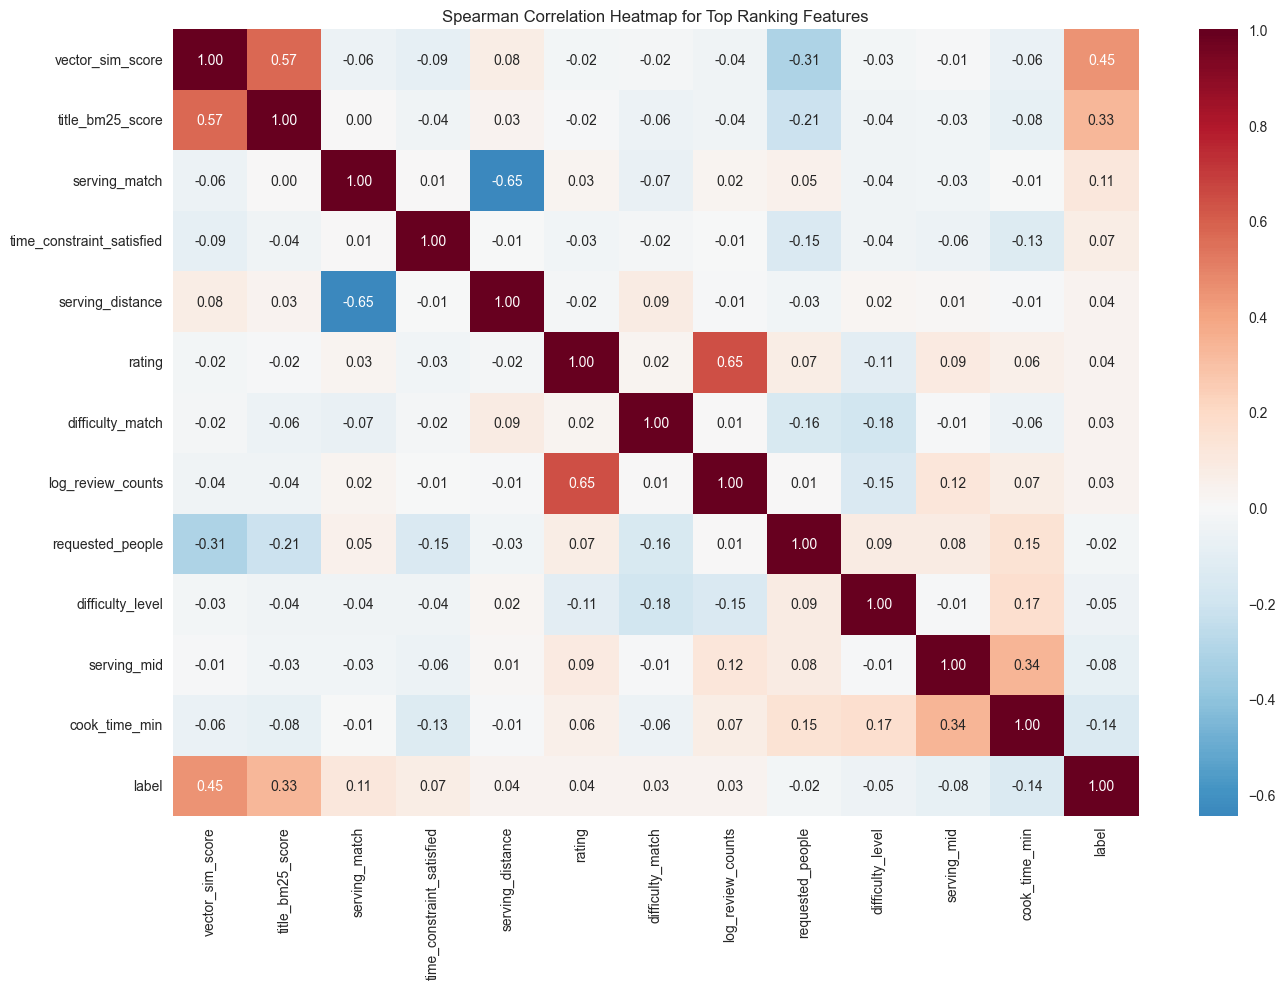

In [7]:
# =========================
# Input validation
# =========================

required_raw_cols = [
    "query", "dish_name", "recipe_id", "ingredients", "category",
    "difficulty", "views", "prep_time_min", "cook_time_min",
    "servings_bin", "popularity",
]

missing_raw_cols = [col for col in required_raw_cols if col not in df.columns]
if missing_raw_cols:
    raise KeyError(f"Thieu cac cot bat buoc truoc khi tao feature: {missing_raw_cols}")


# =========================
# Basic text columns
# =========================

df = df.copy()
df["recipe_text"] = df.apply(build_recipe_text, axis=1)
df["dish_name_norm"] = df["dish_name"].map(normalize_text)
df["query_norm"] = df["query"].map(normalize_text)
df["title_tokens"] = df["dish_name"].map(tokenize)
df["query_tokens"] = df["query"].map(tokenize)

created_feature_cols = [
    "recipe_text",
    "dish_name_norm",
    "query_norm",
    "title_tokens",
    "query_tokens",
]

missing_created_cols = [col for col in created_feature_cols if col not in df.columns]
if missing_created_cols:
    raise KeyError(f"Khong tao duoc cac cot feature co ban: {missing_created_cols}")


# =========================
# Parse each query once with a cache-backed constraint parser
# =========================

query_feature_df = query_constraint_parser.build_query_feature_df(
    df["query"].drop_duplicates(),
    parser=parse_query_constraints,
    cache_path=QUERY_CONSTRAINT_CACHE_PATH,
)

query_parse_cols = [
    "query",
    "servings_target",
    "difficulty_target",
    "prep_time_limit_min",
    "cook_time_limit_min",
    "total_time_limit_min",
    "time_limit_min",
    "max_ingredients",
    "style_tags",
    "categories",
]

cols_to_drop_before_merge = [
    "requested_people",
    "query_difficulty_target",
    "prep_time_limit_min",
    "cook_time_limit_min",
    "total_time_limit_min",
    "time_limit_min",
    "max_ingredients",
    "style_tags",
    "categories",
]

df = df.drop(columns=[c for c in cols_to_drop_before_merge if c in df.columns], errors="ignore")

df = df.merge(
    query_feature_df[query_parse_cols],
    on="query",
    how="left",
)

df = df.rename(
    columns={
        "servings_target": "requested_people",
        "difficulty_target": "query_difficulty_target",
    }
)


# =========================
# Retrieval features
# =========================

recipe_lookup = df[["recipe_id", "dish_name", "recipe_text"]].drop_duplicates("recipe_id").copy()
recipe_lookup["title_tokens"] = recipe_lookup["dish_name"].map(tokenize)

title_corpus = recipe_lookup.set_index("recipe_id")["title_tokens"].to_dict()
bm25_params = build_bm25(list(title_corpus.values()))

recipe_text_by_id = recipe_lookup.set_index("recipe_id")["recipe_text"].to_dict()
query_texts = df["query"].drop_duplicates().tolist()
recipe_ids = recipe_lookup["recipe_id"].tolist()
recipe_texts = [recipe_text_by_id[rid] for rid in recipe_ids]

query_embs = encode_texts_with_bge(query_texts)
recipe_embs = encode_texts_with_bge(recipe_texts)

query_emb_map = {q: emb for q, emb in zip(query_texts, query_embs)}
recipe_emb_map = {rid: emb for rid, emb in zip(recipe_ids, recipe_embs)}


# =========================
# Numeric metadata features
# =========================

df["serving_mid"] = df["servings_bin"].map(parse_servings_bin)
df["total_time_min"] = df["prep_time_min"].fillna(0) + df["cook_time_min"].fillna(0)
df["difficulty_level"] = pd.to_numeric(df["difficulty"], errors="coerce").fillna(0)
df["views"] = pd.to_numeric(df["views"], errors="coerce").fillna(0)
df["log_review_counts"] = np.log1p(df["views"])
df["rating"] = df["popularity"].apply(lambda x: float(POPULARITY_MAP.get(normalize_text(str(x)), 0)))


df["prep_time_margin"] = np.where(
    df["time_limit_min"].notna(),
    df["time_limit_min"] - df["prep_time_min"],
    0.0,
)

df["cook_time_margin"] = np.where(
    df["time_limit_min"].notna(),
    df["time_limit_min"] - df["cook_time_min"],
    0.0,
)

df["total_time_margin"] = np.where(
    df["time_limit_min"].notna(),
    df["time_limit_min"] - df["total_time_min"],
    0.0,
)


# =========================
# Matching features
# =========================

df["title_bm25_score"] = [
    bm25_score(qt, title_corpus[rid], bm25_params)
    for qt, rid in zip(df["query_tokens"], df["recipe_id"])
]

df["vector_sim_score"] = [
    cosine_similarity_dense(query_emb_map[q], recipe_emb_map[rid])
    for q, rid in zip(df["query"], df["recipe_id"])
]


# =========================
# Constraint features
# =========================

df["serving_match"] = (
    df["requested_people"].notna()
    & df["serving_mid"].notna()
    & (np.abs(df["requested_people"] - df["serving_mid"]) <= 1.0)
).astype(float)

df["serving_distance"] = np.where(
    df["requested_people"].notna() & df["serving_mid"].notna(),
    np.abs(df["requested_people"] - df["serving_mid"]),
    99.0,
)

df["difficulty_match"] = (
    df["query_difficulty_target"].notna()
    & (df["query_difficulty_target"] == df["difficulty_level"])
).astype(float)

df["time_constraint_satisfied"] = np.where(
    df["time_limit_min"].notna(),
    (df["prep_time_min"].fillna(10**6) <= df["time_limit_min"])
    & (df["cook_time_min"].fillna(10**6) <= df["time_limit_min"]),
    0,
).astype(float)


# =========================
# Final feature lists
# =========================

corr_feature_cols = [
    "title_bm25_score",
    "vector_sim_score",
    "cook_time_min",
    "prep_time_min",
    "total_time_min",
    "serving_match",
    "serving_mid",
    "serving_distance",
    "requested_people",
    "rating",
    "log_review_counts",
    "time_constraint_satisfied",
    "difficulty_level",
    "difficulty_match",
]

feature_cols = corr_feature_cols.copy()

corr_df = df[corr_feature_cols + ["label"]].corr(method="spearman")
label_corr = corr_df["label"].drop("label").sort_values(ascending=False)
display(label_corr.to_frame("spearman_with_label"))

plt.figure(figsize=(14, 10))
heatmap_cols = list(label_corr.head(12).index) + ["label"]
sns.heatmap(
    df[heatmap_cols].corr(method="spearman"),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
)
plt.title("Spearman Correlation Heatmap for Top Ranking Features")
plt.tight_layout()
plt.show()



## Correlation Analysis

The updated heatmap should now be interpreted using the streamlined feature set built from `BM25`, `BGE-M3`, and the constraint features extracted by `Qwen3`. In this version, `vector_sim_score` captures semantic similarity from multilingual embeddings, while `title_bm25_score` captures lexical overlap at the title level.

Time, serving-size, and difficulty features remain as structured constraint signals. They are expected to be weaker than the main retrieval features individually, but still useful when combined by the XGBoost ranker.

Because the manual category and ingredient matching features were removed, the heatmap is now easier to interpret and less affected by redundant hand-crafted matching signals.


In [8]:
model_df = df.copy()
model_df[feature_cols] = model_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

query_table = (
    model_df.groupby("query")
    .agg(avg_label=("label", "mean"), n_candidates=("query", "size"))
    .reset_index()
)

train_queries, temp_queries = train_test_split(
    query_table["query"],
    test_size=0.30,
    random_state=RANDOM_STATE,
)
val_queries, test_queries = train_test_split(
    temp_queries,
    test_size=0.50,
    random_state=RANDOM_STATE,
)


def make_split(split_queries):
    split_df = model_df[model_df["query"].isin(split_queries)].copy()
    split_df = split_df.sort_values(["query", "recipe_id"]).reset_index(drop=True)
    X = split_df[feature_cols]
    y = split_df["label"].astype(float)
    group = split_df.groupby("query").size().tolist()
    return split_df, X, y, group


train_df, X_train, y_train, group_train = make_split(train_queries)
val_df, X_val, y_val, group_val = make_split(val_queries)
test_df, X_test, y_test, group_test = make_split(test_queries)

print("Train queries:", train_df["query"].nunique(), "rows:", len(train_df))
print("Val queries:", val_df["query"].nunique(), "rows:", len(val_df))
print("Test queries:", test_df["query"].nunique(), "rows:", len(test_df))
print("Feature count:", len(feature_cols))


Train queries: 175 rows: 2625
Val queries: 37 rows: 555
Test queries: 38 rows: 570
Feature count: 14


In [9]:
def compute_group_metrics(eval_df, score_col="pred_score", top_ks=(5, 10)):
    rows = []
    ndcg_store = defaultdict(list)
    mrr_store = []
    hit_store = {k: [] for k in top_ks}

    for query, group in eval_df.groupby("query"):
        group = group.sort_values(score_col, ascending=False).reset_index(drop=True)
        y_true = group["label"].to_numpy(dtype=float)
        y_score = group[score_col].to_numpy(dtype=float)

        for k in top_ks:
            ndcg_k = ndcg_score([y_true], [y_score], k=min(k, len(group)))
            ndcg_store[k].append(float(ndcg_k))

        relevant_positions = np.where(group["label"].to_numpy() >= 4)[0]
        if len(relevant_positions) > 0:
            mrr_store.append(1.0 / (relevant_positions[0] + 1))
        else:
            mrr_store.append(0.0)

        for k in top_ks:
            hit_store[k].append(float((group["label"].head(k) >= 4).any()))

    metrics = {}
    for k in top_ks:
        metrics[f"NDCG@{k}"] = float(np.mean(ndcg_store[k]))
    metrics["MRR"] = float(np.mean(mrr_store))
    for k in top_ks:
        metrics[f"HIT@{k}"] = float(np.mean(hit_store[k]))
    return metrics

baseline_test = test_df.copy()
baseline_test["pinecone_rank"] = baseline_test.groupby("query").cumcount() + 1
baseline_test["baseline_score"] = -baseline_test["pinecone_rank"]

baseline_metrics = compute_group_metrics(baseline_test, score_col="baseline_score")
print("Baseline metrics:")
for name, value in baseline_metrics.items():
    print(f"{name}: {value:.4f}")
        


Baseline metrics:
NDCG@5: 0.5038
NDCG@10: 0.6204
MRR: 0.3127
HIT@5: 0.4474
HIT@10: 0.5526


In [10]:
ranker = XGBRanker(
    objective="rank:pairwise",
    eval_metric=["ndcg@5", "ndcg@10"],
    learning_rate=0.05,
    n_estimators=400,
    max_depth=6,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    tree_method="hist",
    random_state=RANDOM_STATE,
)

start_time = time.time()
ranker.fit(
    X_train,
    y_train,
    group=group_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_group=[group_train, group_val],
    verbose=False,
)
train_seconds = time.time() - start_time

print(f"Training finished in {train_seconds:.2f} seconds")
        


Training finished in 2.19 seconds


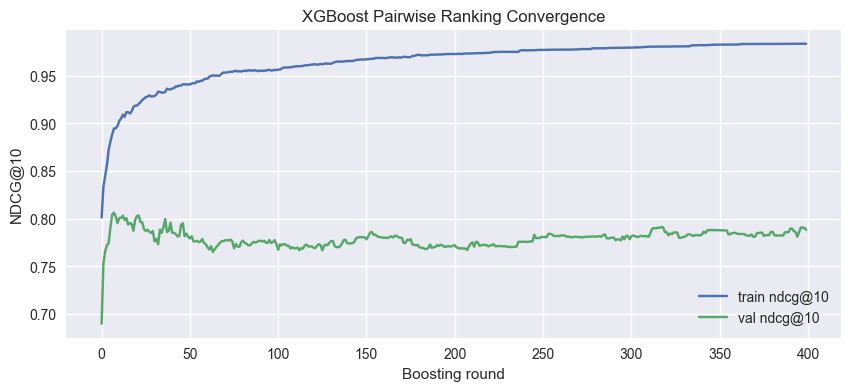

In [11]:
evals_result = ranker.evals_result()

plt.figure(figsize=(10, 4))
plt.plot(evals_result["validation_0"]["ndcg@10"], label="train ndcg@10")
plt.plot(evals_result["validation_1"]["ndcg@10"], label="val ndcg@10")
plt.title("XGBoost Pairwise Ranking Convergence")
plt.xlabel("Boosting round")
plt.ylabel("NDCG@10")
plt.legend()
plt.show()
        


In [12]:
test_pred_start = time.time()
test_df = test_df.copy()
test_df["pred_score"] = ranker.predict(X_test)
infer_seconds = time.time() - test_pred_start

test_metrics = compute_group_metrics(test_df, score_col="pred_score")

comparison_df = pd.DataFrame([
    {"model": "Pinecone baseline", **baseline_metrics, "train_seconds": 0.0, "infer_seconds": 0.0},
    {"model": "XGBoost rank:pairwise", **test_metrics, "train_seconds": train_seconds, "infer_seconds": infer_seconds},
])
comparison_df
        


,model,NDCG@5,NDCG@10,MRR,HIT@5,HIT@10,train_seconds,infer_seconds
0,Pinecone baseline,0.503846,0.620449,0.312678,0.447368,0.552632,0.000000,0.00000
1,XGBoost rank:pairwise,0.757881,0.829385,0.526096,0.657895,0.710526,2.193746,0.02465


,feature,importance
11,time_constraint_satisfied,0.098224
7,serving_distance,0.094643
5,serving_match,0.086015
1,vector_sim_score,0.082795
12,difficulty_level,0.077381
0,title_bm25_score,0.075503
4,total_time_min,0.065879
8,requested_people,0.063998
10,log_review_counts,0.063186
6,serving_mid,0.061905


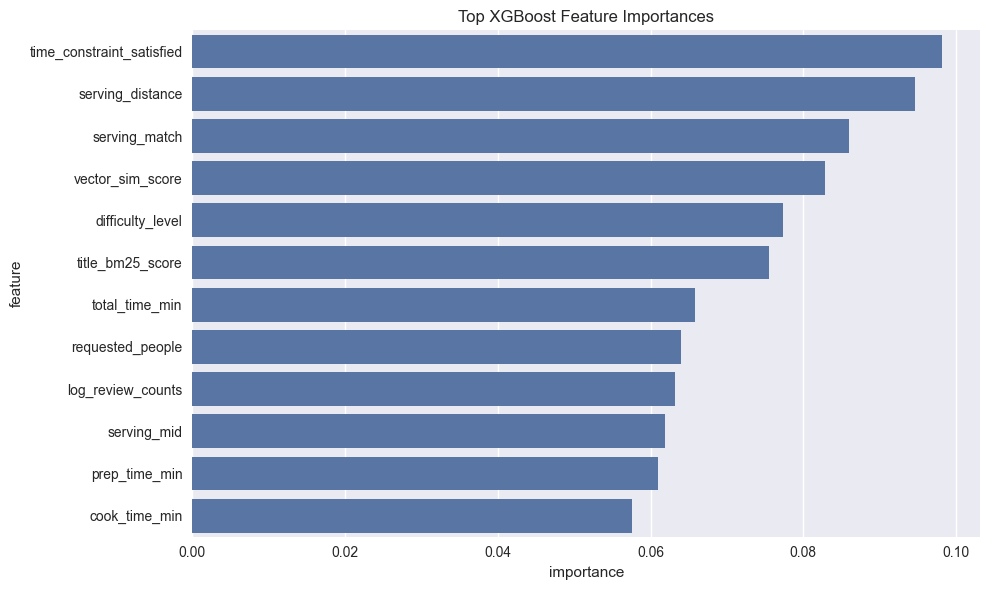

In [13]:
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": ranker.feature_importances_,
}).sort_values("importance", ascending=False)

display(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(12), x="importance", y="feature")
plt.title("Top XGBoost Feature Importances")
plt.tight_layout()
plt.show()
        


In [14]:
ablations = {
    "full": feature_cols,
    "without_support_signals": [c for c in feature_cols if c not in {"rating", "log_review_counts"}],
    "without_constraint_flags": [c for c in feature_cols if c not in {"time_constraint_satisfied", "difficulty_match"}],
}

ablation_rows = []
for ablation_name, cols in ablations.items():
    local_train = train_df[cols]
    local_val = val_df[cols]
    local_test = test_df[cols]

    local_ranker = XGBRanker(
        objective="rank:pairwise",
        eval_metric="ndcg@10",
        learning_rate=0.05,
        n_estimators=250,
        max_depth=6,
        min_child_weight=3,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.0,
        tree_method="hist",
        random_state=RANDOM_STATE,
    )
    local_ranker.fit(
        local_train,
        y_train,
        group=group_train,
        eval_set=[(local_val, y_val)],
        eval_group=[group_val],
        verbose=False,
    )
    local_scores = local_ranker.predict(local_test)
    local_eval = test_df.copy()
    local_eval["pred_score"] = local_scores
    metrics = compute_group_metrics(local_eval, score_col="pred_score")
    ablation_rows.append({"setting": ablation_name, **metrics, "n_features": len(cols)})

pd.DataFrame(ablation_rows).sort_values("NDCG@10", ascending=False)
        


,setting,NDCG@5,NDCG@10,MRR,HIT@5,HIT@10,n_features
1,without_support_signals,0.786491,0.833961,0.529386,0.657895,0.710526,12
0,full,0.748306,0.821243,0.506683,0.631579,0.710526,14
2,without_constraint_flags,0.761635,0.813837,0.516447,0.684211,0.710526,12


## Notes for the report

- This notebook uses **query-level splitting** to avoid leakage.
- The model is an **XGBoost learning-to-rank model** with `objective="rank:pairwise"`.
- The feature set combines:
  - lexical matching (`title_bm25_score`)
  - constraint signals (`time_constraint_satisfied`, `difficulty_match`, `serving_match`, `serving_distance`)
  - semantic similarity (`vector_sim_score` from BGE-M3 embeddings)
  - popularity priors (`rating`, `log_review_counts`)
- Since the current repository does not contain `rating` or `review_counts` explicitly, the notebook maps:
  - `rating <- popularity`
  - `log_review_counts <- log1p(views)`
